# Project Exploration

This notebook is her to understand the basic data structures present in the project.
It's more of an exploratory pointer than an actual notebook.

Prerequisites:
- You should have downloaded the twooroom dataset and placed it under <STABLEWM_HOME>/datasets
- You have to run the LeWorldModel training to a point where you have at least one snapshot.
   - Alterntively, you can download a .pt file from huggingface and place it in the <STABLEWM_HOME>/checkpoints directory)

In [1]:
# correct working directory only once 
if not "working_directory_corrected" in vars():
    %cd ..
    working_directory_corrected = True

import os
import stable_worldmodel as swm
import h5py
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import random

c:\Users\frank\Documents\Teaching\Projects\JEPAHeuristics\JEPAHeuristics


c:\Users\frank\Documents\Teaching\Projects\JEPAHeuristics\JEPAHeuristics\environment\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Dataset
Here we load the dataset tworoom and obsere it's properties.

The below cell loads the dataset and prints out all properties.

In [9]:
cache_dir = os.environ.get("LOCAL_DATASET_DIR", None)
dataset = swm.data.load_dataset(
    "tworoom.h5", 
    transform=None, 
    cache_dir=cache_dir, 
    format="hdf5"
)

dataset[0].keys()

dict_keys(['action', 'distance_to_target', 'ep_idx', 'id', 'observation', 'pixels', 'pos_agent', 'pos_target', 'proprio', 'render_time', 'reward', 'step_idx', 'terminated', 'truncated'])

For us, the main properties are the following:
- "pixels": a representation of the image in rgb images with resolution 224 x 224
- "pos_agent": the position of the agent on the image in two-dimensional coordinates between (0,0) and (244,244)
- "action": the action performed at the current point. Seems to a two-dimenional movement vector between (-1,-1) and (1,1)

Let's visualize the image data now (column pixels). Below we'll visualize nine random states from the dataset.

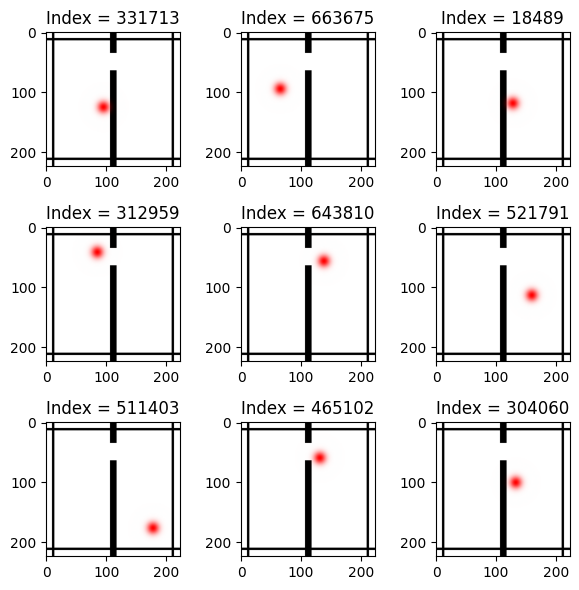

In [10]:

fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(3*2, 3*2))
for index in range(9):
    data_index = random.randint(0,len(dataset))
    axes[index//3][index%3].set_title(label=f"Index = {data_index}")
    # pytorch format is (3,244,244). Need to permute into (244,244,3)
    axes[index//3][index%3].imshow(dataset[data_index]["pixels"][0].permute(1,2,0))

plt.tight_layout()

Next, let us illustrate the meaning of "pos_agent" and "action".
"pos_agent" is the current position of the agent. It should coincide with the center of the red dot showin in the image. 

"action" is the action performed in the current state. It takes effect in the next one. This means an action performed in image 0 will have an effect in image 1 and move the position of the agent. Empirically, it seems that the agent will move 5 times the action vector. This means, we can predict the next position with the following formula:

- $next\_position = current\_position + action*5$

Below we can test this formula. No matter which index within the dataset you choose, the predicted next position should always be the same - or very close to - the actual next position.


In [11]:
index = 0

print("state", dataset[index]["pos_agent"])
print("action", dataset[index]["action"])
print("predicted next state", dataset[index]["pos_agent"] + 5*dataset[index]["action"])
print("next state",dataset[index+1]["pos_agent"])


state tensor([[169.4324,  65.9336]])
action tensor([[-0.4363, -1.0000]])
predicted next state tensor([[167.2509,  60.9336]])
next state tensor([[167.2509,  60.9336]])


# FROM HERE WORK IN PROGRESS


# Model

Now let's get the model into play and load it.
The cell below loads the model. It assumes you have a snapshot located at <STABLEWM_HOME>/checkpoints/lewm/weights_epoch_100.pt. If your checkpoint is somewhere else (e.g., because you have downloaded form huggingface) you will need to adjust the location in the cell below.

Note that below we also re-load 

In [5]:
cache_dir = os.environ.get("LOCAL_DATASET_DIR", None)
dataset = swm.data.load_dataset(
    "tworoom.h5", 
    transform=None, 
    cache_dir=cache_dir, 
    format="hdf5", 
    frameskip = 5,
    keys_to_load = ["pixels", "action", "proprio"],
    keys_to_cache= ["action", "proprio"]
    
)

model = swm.wm.utils.load_pretrained("lewm/weights_epoch_100.pt")

c:\Users\frank\Documents\Teaching\Projects\JEPAHeuristics\JEPAHeuristics\environment\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


11:02:44 | INFO  | __init__.py | JAX version 0.6.2 available.
11:02:44 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)
11:02:44 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}


In [6]:

data_loader = DataLoader(dataset, batch_size=100)
batch = next(iter(data_loader))
batch["action"] = torch.nan_to_num(batch["action"], 0.0)
batch = model.encode(batch)

In [7]:
print(batch["action"])

tensor([[[-0.4363, -1.0000, -1.0000,  1.0000, -0.3437, -0.5173, -1.0000,
          -1.0000, -0.2429,  1.0000]],

        [[-1.0000,  1.0000, -0.3437, -0.5173, -1.0000, -1.0000, -0.2429,
           1.0000, -0.6653, -0.3743]],

        [[-0.3437, -0.5173, -1.0000, -1.0000, -0.2429,  1.0000, -0.6653,
          -0.3743, -1.0000,  0.1905]],

        [[-1.0000, -1.0000, -0.2429,  1.0000, -0.6653, -0.3743, -1.0000,
           0.1905, -0.8120,  1.0000]],

        [[-0.2429,  1.0000, -0.6653, -0.3743, -1.0000,  0.1905, -0.8120,
           1.0000, -1.0000, -1.0000]],

        [[-0.6653, -0.3743, -1.0000,  0.1905, -0.8120,  1.0000, -1.0000,
          -1.0000, -0.7065, -0.9432]],

        [[-1.0000,  0.1905, -0.8120,  1.0000, -1.0000, -1.0000, -0.7065,
          -0.9432,  0.7782,  0.0447]],

        [[-0.8120,  1.0000, -1.0000, -1.0000, -0.7065, -0.9432,  0.7782,
           0.0447, -1.0000,  0.6388]],

        [[-1.0000, -1.0000, -0.7065, -0.9432,  0.7782,  0.0447, -1.0000,
           0.6388, -0.4

In [ ]:
result = model.predict(batch["emb"],batch["act_emb"])

In [ ]:
result

tensor([[[-0.9290,  0.3025,  0.4081,  ...,  0.6456,  1.8487,  0.1907]],

        [[-1.1133,  1.9977,  0.6754,  ...,  1.2744, -0.3176, -0.0778]],

        [[-0.2307,  0.0859,  0.8876,  ...,  0.6285,  0.5026,  0.4282]],

        ...,

        [[-0.9426, -0.8330, -1.1227,  ...,  0.1626, -1.6638,  0.7575]],

        [[ 2.2948,  0.3496, -0.9406,  ..., -1.1386,  0.1017,  0.6076]],

        [[ 0.6957, -2.2435,  1.8347,  ...,  0.2901,  0.2579,  1.3753]]],
       grad_fn=<ViewBackward0>)

In [ ]:
print("result", result[0])
print("embedding", batch["emb"][5])

result tensor([[-0.9290,  0.3025,  0.4081,  0.2269,  0.7172,  0.1438, -0.8319, -1.2434,
          1.6633,  0.4681, -0.8837,  0.5602,  0.0875, -0.0866,  0.1104,  0.9511,
          0.2642, -0.4826, -0.8067, -0.2844,  1.0595,  0.0913,  0.7076,  1.0401,
         -0.6914,  0.8849,  0.1924, -0.1490, -1.3798,  0.4971, -1.2334, -0.3981,
         -0.6346, -0.6759,  0.3088, -0.1332,  0.4845, -0.4240, -0.8538, -1.6813,
          0.5983, -0.5035,  0.7201, -0.1505, -0.3714, -0.3004,  1.2280,  0.6300,
          0.5974,  2.3570, -0.9149, -1.1381, -0.4035,  0.2022,  0.3892, -0.0481,
          0.6497, -1.8009,  0.1979,  0.3631, -0.0794,  0.1854, -1.5203, -0.9562,
          1.0299, -0.1779, -1.2290,  0.0042, -0.3268,  0.7188,  0.5084,  0.5758,
          0.5340, -1.1035,  1.2495,  0.2099,  0.2712,  1.2045, -0.0591, -1.8791,
         -0.1951,  1.7237,  0.3008, -0.2098, -0.4456, -0.3608,  0.4410,  0.6298,
         -1.2448,  0.0326,  0.0105,  0.6194, -0.2235,  1.8696,  0.7479,  1.0228,
          0.3488, -0.

In [ ]:
batch["act_emb"][0]

tensor([[-2.0001e+00,  8.3561e-01,  1.8576e-01, -7.9717e-01, -4.1219e+00,
          1.6654e+00, -1.0468e+00,  1.2437e+00, -1.9166e+00,  1.9401e-01,
         -2.7504e-01, -1.3264e+00,  9.4556e-01, -2.9468e-02, -1.6219e+00,
         -7.6295e-01,  2.4845e-01, -2.1916e+00, -1.2192e+00, -2.3742e+00,
          7.5463e-01, -2.2428e+00, -6.1043e-01,  9.4565e-01, -2.5371e-02,
         -6.1134e-01, -7.0107e-01,  1.2359e+00, -1.3904e+00,  2.0478e-01,
          7.1440e-01,  2.1173e-01,  2.8204e-01,  2.5580e-01,  4.8870e-01,
         -2.1496e-01, -5.6605e-01,  5.7591e-01, -2.4665e-01,  1.2827e+00,
         -6.7238e-01, -5.6170e-01, -9.4688e-01,  4.2352e-01,  7.4092e-02,
          3.0366e-01,  7.4546e-01,  6.9835e-01,  1.4288e+00, -5.8087e-01,
         -1.9630e+00,  4.5699e-01,  6.1345e-01,  5.7029e-01, -1.2140e+00,
          7.6425e-01, -1.1488e+00, -2.0589e-01, -1.2604e+00, -1.4349e+00,
         -1.7830e-01,  7.0879e-01,  4.5443e-01, -1.5231e+00, -2.0235e+00,
         -1.4537e+00, -5.3181e-01, -3.

TODO: currently training a model with 2 action channels. 